In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2

!pip install line_profiler
%load_ext line_profiler
    
mne.set_log_level('ERROR')
tl.get_backend()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=64, tmin=-0.2)
dataset = BNCI2014009()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,-0.203 – 0.781 s
Baseline,off


In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

nfreqs=16

X = epochs.get_data()
y = labels

X.shape

(576, 16, 64)

In [10]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.backend import lobpcg
import cupyx.scipy.sparse.linalg
import warnings

from hoda.hoda import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

hoda = HODA(
        rank=4,
        max_iter=128,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=True,
        verbose=True,
        delta=None,
        ortho=False,
        forward=False,
        random_state=42,

)

display(hoda)


HODA(extra_train_info=True, init='random', max_iter=128, random_state=42,
     rank=4, taper=True, tol=1e-12, verbose=True)

  0%|          | 0/128 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,rank,objective,F_tr,F_rt
0,1,0,3.160041e-02,0.001597,4,0.158235,0.048825,0.002307
1,1,1,7.387731e-03,0.028910,4,0.567880,0.165444,0.008644
2,2,0,1.647323e-02,0.001437,4,0.643910,0.194115,0.010176
3,2,1,3.863399e-03,0.030052,4,0.705155,0.206595,0.010828
4,3,0,7.082737e-04,0.001424,4,0.708640,0.212345,0.011113
...,...,...,...,...,...,...,...,...
223,112,1,2.623882e-13,0.033321,4,0.752167,0.220745,0.011274
224,113,0,1.105731e-12,0.001518,4,0.740649,0.220745,0.011273
225,113,1,2.353907e-13,0.033321,4,0.752168,0.220745,0.011273
226,114,0,9.919444e-13,0.001518,4,0.740649,0.220745,0.011273


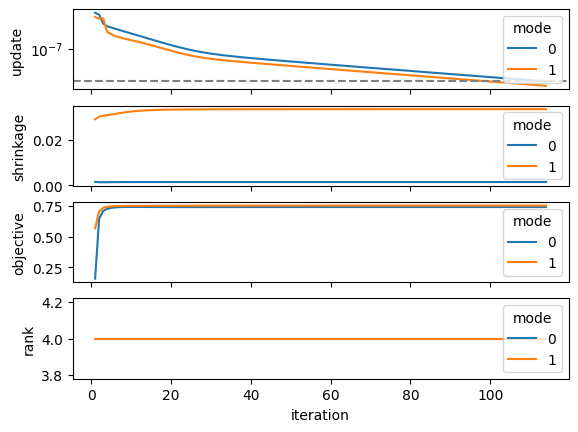

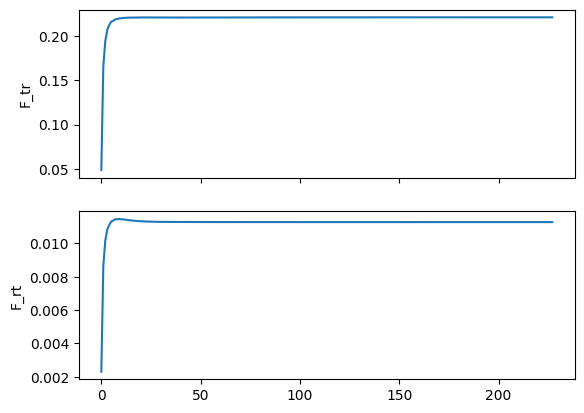

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

  0%|          | 0/128 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,mse,err_cross_corr
0,0,0,inf,NaN,0.945173,0.006920
1,0,1,inf,NaN,0.945173,0.006920
2,1,0,1.576210e+02,0.095934,0.931091,0.006072
3,1,1,1.369439e-02,0.060264,0.878969,0.002458
4,2,0,3.936958e-04,0.102838,0.877418,0.002358
...,...,...,...,...,...,...
251,125,1,2.171977e-08,0.054988,0.877275,0.002340
252,126,0,8.729026e-08,0.087425,0.877276,0.002340
253,126,1,2.171977e-08,0.054988,0.877275,0.002340
254,127,0,8.729026e-08,0.087425,0.877276,0.002340


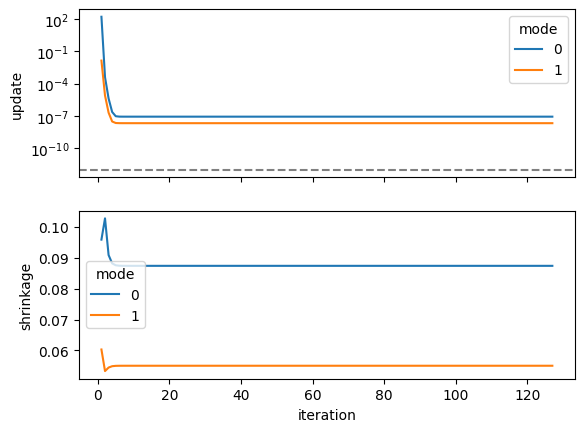

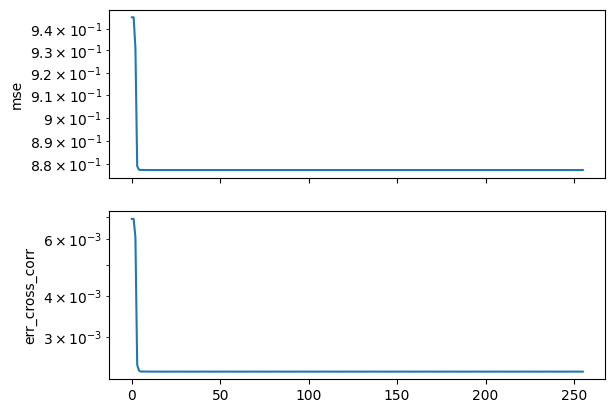

In [49]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='mse', ax=axs[0])
    axs[0].set_yscale('log')
    sns.lineplot(data=df, x=df.index, y='err_cross_corr', ax=axs[1])
    axs[1].set_yscale('log')


In [50]:
import math
from hoda.util import center

X = tl.tensor(X)
G = hoda.transform(X)
X_approx = hoda.inv_transform(G)
err = X-X_approx


<Axes: >

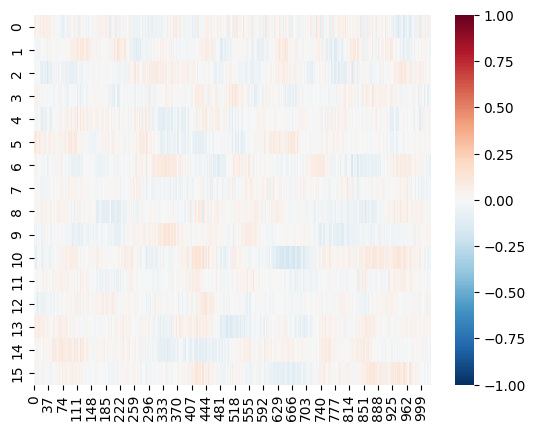

In [51]:
n_samples = X.shape[0]
G_flat = tl.to_numpy(G.reshape((n_samples, -1), order='F'), )
err_flat = tl.to_numpy(err.reshape((n_samples, -1), order='F'))
cross_corr = np.corrcoef(G_flat, err_flat, rowvar=False)
cross_corr = cross_corr[G_flat.shape[-1]:,:G_flat.shape[-1]].T
sns.heatmap(cross_corr,  cmap='RdBu_r', center=0, vmin=-1, vmax=1)

0.007443555492980696


<Axes: >

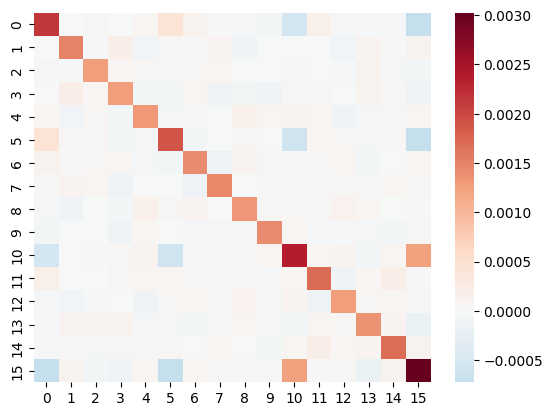

In [52]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
G_flat = G.reshape(n_samples, -1)
G_cov = G_flat.T@G_flat/(n_samples -1)
print(tl.norm(G_cov))
sns.heatmap(tl.to_numpy(G_cov),  cmap='RdBu_r', center=0)

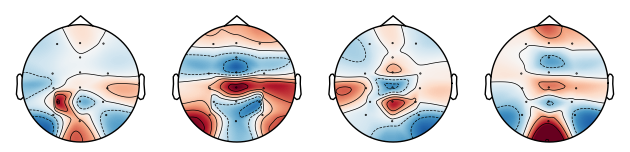

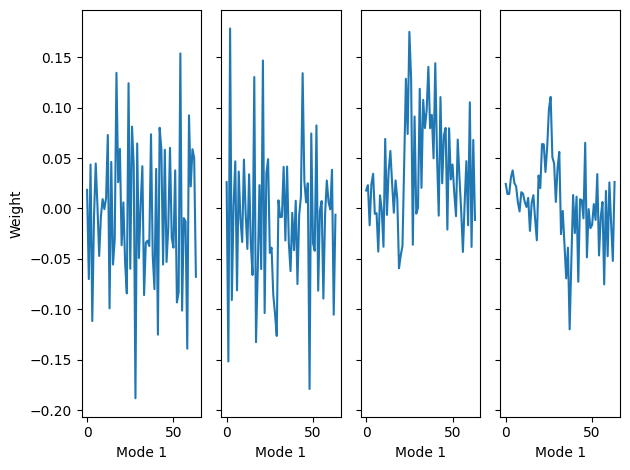

In [53]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');


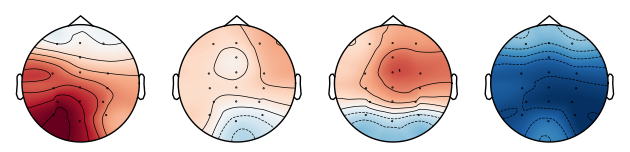

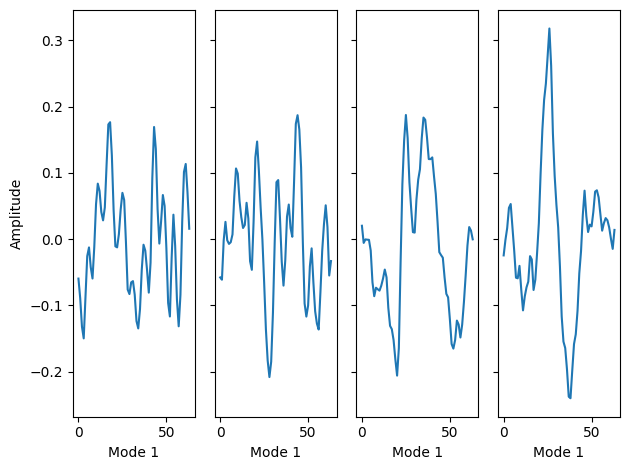

In [54]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

In [47]:
Xt = hoda.transform(X)

[[3.07840819e-19 9.99993332e-01 9.99994583e-01 9.99997167e-01]
 [9.99992310e-01 1.08799267e-32 1.00000000e+00 9.99996829e-01]
 [9.99995607e-01 9.99999715e-01 1.76079821e-56 9.99999077e-01]
 [9.99996370e-01 9.99995575e-01 9.99999303e-01 1.98981102e-77]]


<BarContainer object of 4 artists>

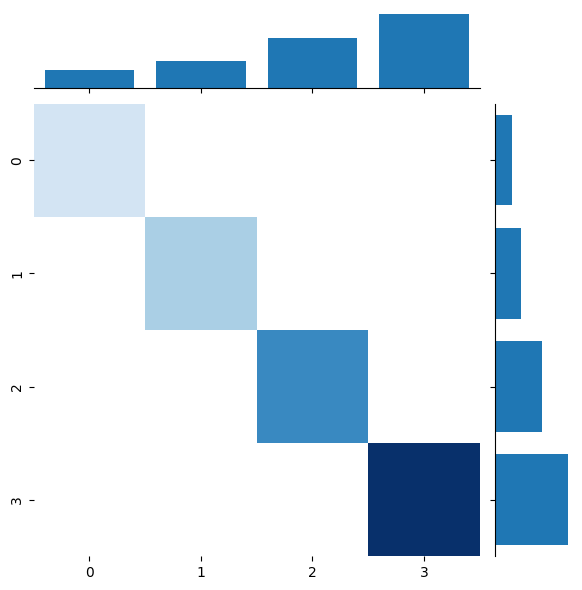

In [48]:
from hoda.util import f_multiway, f_oneway

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)
print(p)
g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.5/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)



<Axes: >

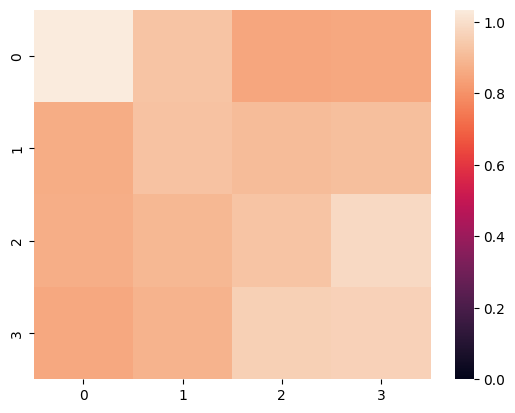

In [21]:
_,Xt_centered = center(Xt, y)
norm = tl.norm(Xt_centered, axis=0)
sns.heatmap(tl.to_numpy(norm), vmin=0)

In [22]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 16)

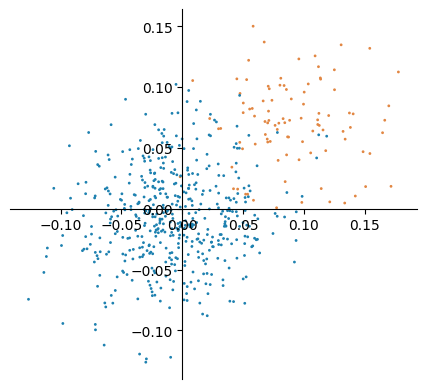

In [23]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt_flat.shape[-1] > 1:
    n_components = 2
    Xt_best = np.hstack([tl.to_numpy(Xt[:,-1,-1, np.newaxis]), tl.to_numpy(Xt[:,-2,-2, np.newaxis])])
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_best[:,0], Xt_best[:,1], c=c, s=1)
    ax.set_aspect('equal')
    ax.spines[["left", "bottom"]].set_position(("data", 0))
    #ax.set_xlim([-5,5])
    #ax.set_ylim([-5,5])
    # Hide the top and right spines.
    ax.spines[["top", "right"]].set_visible(False)


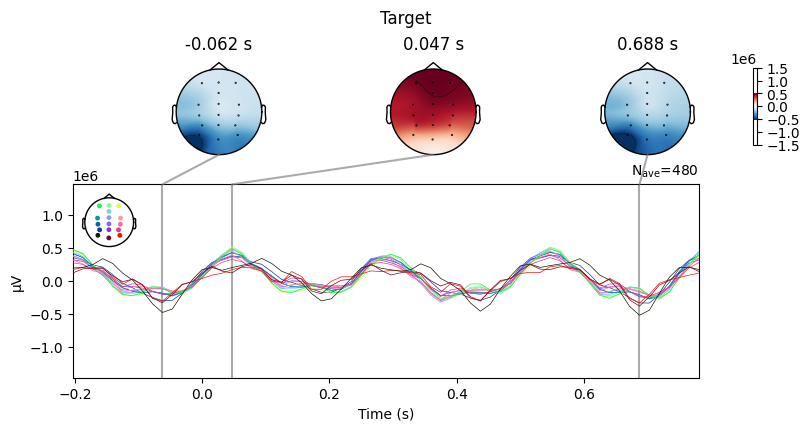

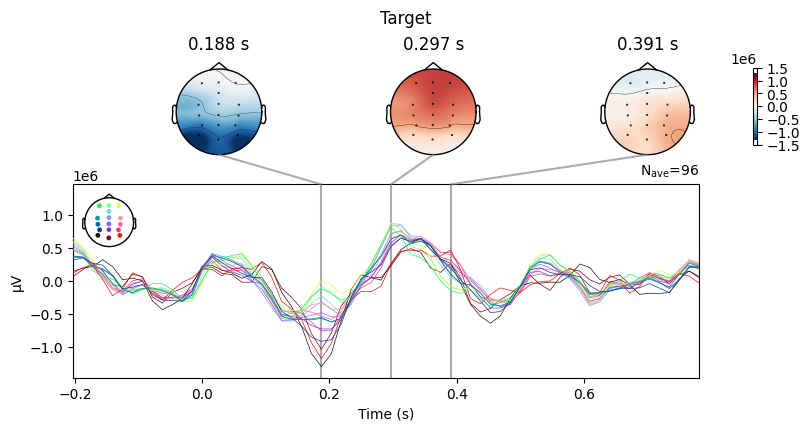

In [24]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.apply_baseline((None,0)).plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

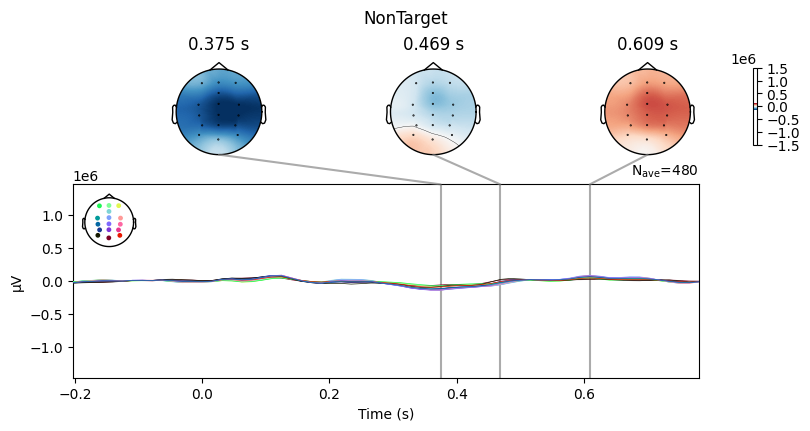

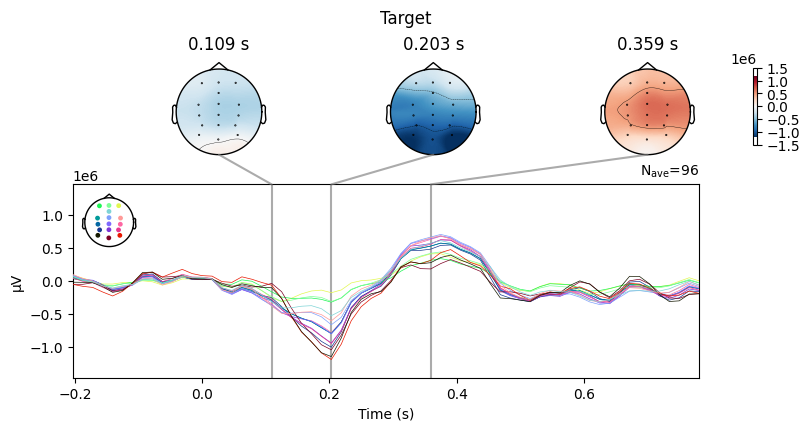

In [25]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.apply_baseline((None,0)).plot_joint(title=cls,
                              **joint_args
                             )
    else:
        evoked_rec.plot(**ts_args)

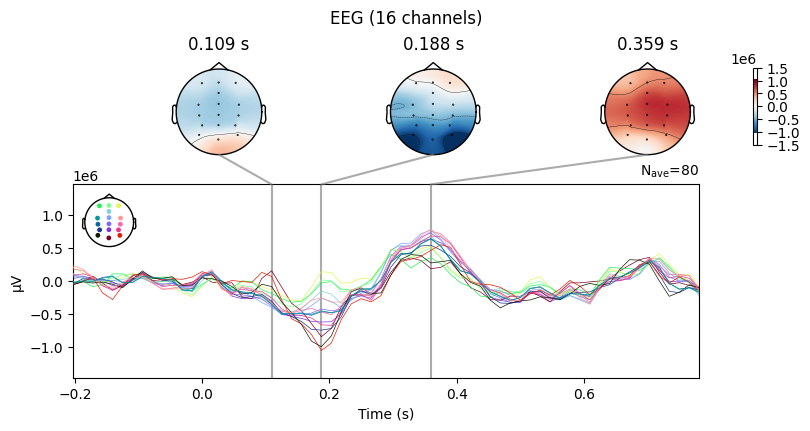

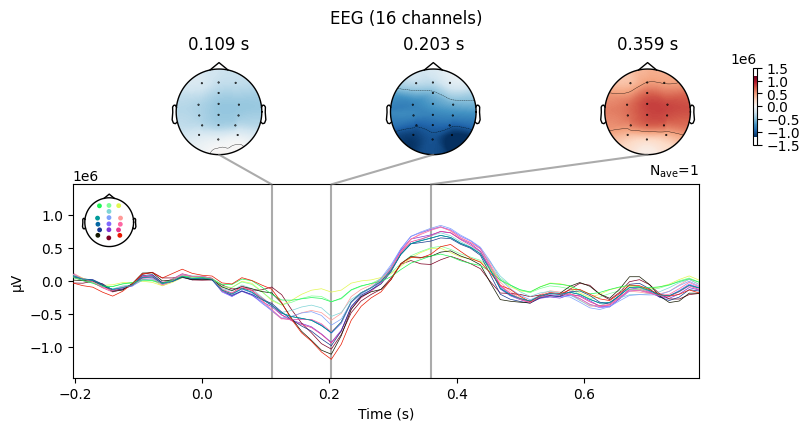

In [26]:
from mne import combine_evoked, EvokedArray

contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(
    **joint_args
)


means_rec = hoda.inv_transform(hoda.transform(hoda.means_))
contrast_rec = means_rec[1]-means_rec[0]
contrast_rec = EvokedArray(tl.to_numpy(contrast_rec), epochs.info, epochs.tmin)
_ = contrast_rec.apply_baseline((None,0)).plot_joint(
    **joint_args
)

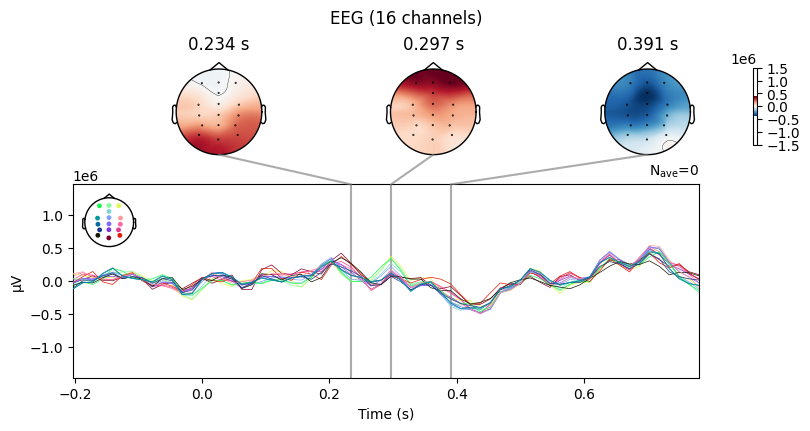

In [27]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.apply_baseline((None,0)).plot_joint(
    **joint_args
)